In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import seaborn as sns

print(" Setting up Grad-CAM visualization")
print("="*70)

# Paths
CONFIG = {
    'models_dir': 'C:\Python\ML Intro\Projects\Medical Image Classification\models',
    'results_dir': 'C:\Python\ML Intro\Projects\Medical Image Classification\results',
    'data_dir': 'C:\Python\ML Intro\Projects\Medical Image Classification\data\chest_xray',
}

# Load your best model
model_path = str(Path(CONFIG['models_dir']) / 'mobilenet_best.h5')
model = keras.models.load_model(model_path)

print(f" Model loaded from: {model_path}")
print(f"   Model accuracy: 91%")

 Setting up Grad-CAM visualization
 Model loaded from: C:\Python\ML Intro\Projects\Medical Image Classification\models\mobilenet_best.h5
   Model accuracy: 91%


In [25]:
def get_gradcam_model(original_model):
    """
    Create a new model suitable for Grad-CAM by flattening the nested structure
    """
    # Get the nested base model
    base_model = original_model.get_layer('mobilenetv2_1.00_224')
    
    # Find the last convolutional layer in MobileNetV2
    last_conv_layer = None
    for layer in reversed(base_model.layers):
        if isinstance(layer, keras.layers.Conv2D):
            last_conv_layer = layer
            break
    
    if last_conv_layer is None:
        # Try by name
        try:
            last_conv_layer = base_model.get_layer('Conv_1')
        except:
            # Use the output of the entire base model
            print("  Could not find Conv layer, using base model output")
            last_conv_layer = base_model
    
    print(f" Using layer for Grad-CAM: {last_conv_layer.name}")
    
    # Build a NEW model that connects properly
    # Input -> Base Model layers -> Conv output + Final prediction
    inputs = keras.Input(shape=(224, 224, 3))
    
    # Pass through base model
    x = base_model(inputs)
    
    # Get the conv output we want
    # Since we can't access intermediate layers of a nested model easily,
    # we'll use the base model's output
    conv_output = x
    
    # Continue through the rest of the original model
    x = model.get_layer('global_average_pooling2d')(x)
    x = model.get_layer('dropout')(x)
    x = model.get_layer('dense')(x)
    x = model.get_layer('dropout_1')(x)
    predictions = model.get_layer('dense_1')(x)
    
    # Create new model
    grad_model = keras.Model(inputs=inputs, outputs=[conv_output, predictions])
    
    return grad_model


def make_gradcam_heatmap(img_array, grad_model):
    """
    Generate Grad-CAM heatmap using the rebuilt model
    """
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]  # Binary classification
    
    # Get gradients of the loss with respect to conv outputs
    grads = tape.gradient(loss, conv_outputs)
    
    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Weight the conv outputs
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val
    
    return heatmap.numpy()


def save_and_display_gradcam(img_path, heatmap, cam_path, alpha=0.4):
    """
    Overlay Grad-CAM heatmap on original image
    """
    # Load the original image
    img = keras.preprocessing.image.load_img(img_path)
    img = keras.preprocessing.image.img_to_array(img)
    
    # Rescale heatmap to range 0-255
    heatmap = np.uint8(255 * heatmap)
    
    # Use jet colormap
    jet = plt.cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    # Create colored heatmap
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
    
    # Superimpose
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)
    
    # Save
    superimposed_img.save(cam_path)
    
    return superimposed_img


print(" Grad-CAM functions defined")

# Create the Grad-CAM compatible model
print("\n Building Grad-CAM model...")
gradcam_model = get_gradcam_model(model)
print(" Grad-CAM model ready")

 Grad-CAM functions defined

 Building Grad-CAM model...
 Using layer for Grad-CAM: Conv_1
 Grad-CAM model ready



 GENERATING GRAD-CAM FOR NORMAL CASES


C:\Users\Adhiraj\AppData\Local\Temp\ipykernel_2416\231729030.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


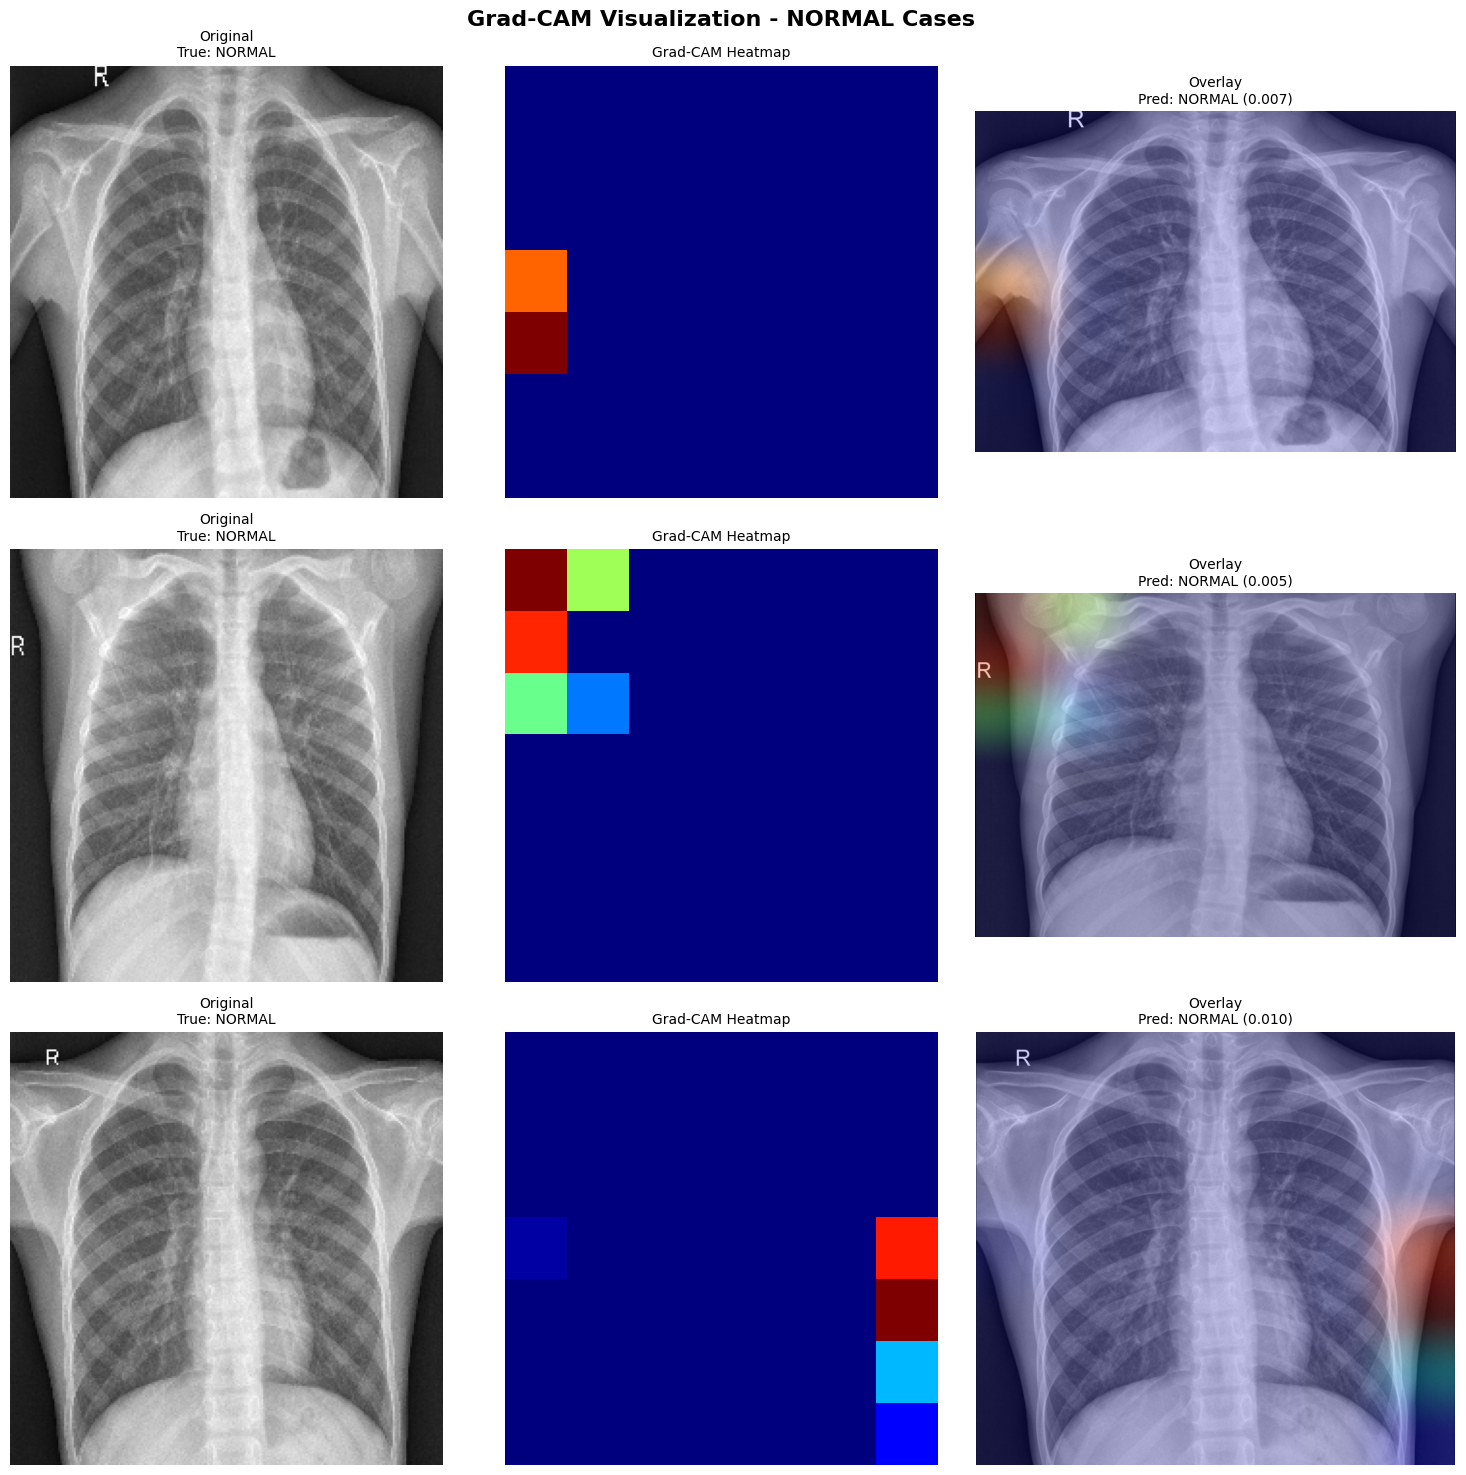

 Grad-CAM visualizations saved to: C:\Python\ML Intro\Projects\Medical Image Classification\results\plots\gradcam


In [27]:
print("\n" + "="*70)
print(" GENERATING GRAD-CAM FOR NORMAL CASES")
print("="*70)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

gradcam_dir = Path(r'C:\Python\ML Intro\Projects\Medical Image Classification\results\plots\gradcam')
gradcam_dir.mkdir(parents=True, exist_ok=True)

for idx, img_path in enumerate(normal_images):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    
    # Get prediction
    pred = model.predict(img_array, verbose=0)[0][0]
    pred_class = "PNEUMONIA" if pred > 0.5 else "NORMAL"
    
    # Generate heatmap using the rebuilt model
    heatmap = make_gradcam_heatmap(img_array, gradcam_model)
    
    # Save Grad-CAM overlay
    cam_path = gradcam_dir / f'normal_{idx}_gradcam.jpg'
    superimposed_img = save_and_display_gradcam(str(img_path), heatmap, str(cam_path))
    
    # Display
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f'Original\nTrue: NORMAL', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(heatmap, cmap='jet')
    axes[idx, 1].set_title(f'Grad-CAM Heatmap', fontsize=10)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(superimposed_img)
    axes[idx, 2].set_title(f'Overlay\nPred: {pred_class} ({pred:.3f})', fontsize=10)
    axes[idx, 2].axis('off')

plt.suptitle('Grad-CAM Visualization - NORMAL Cases', fontsize=16, fontweight='bold')
plt.tight_layout()

save_path = gradcam_dir / 'gradcam_normal_cases.png'
plt.savefig(str(save_path), dpi=300, bbox_inches='tight')
plt.show()

print(f" Grad-CAM visualizations saved to: {gradcam_dir}")


 GENERATING GRAD-CAM FOR PNEUMONIA CASES


C:\Users\Adhiraj\AppData\Local\Temp\ipykernel_2416\231729030.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


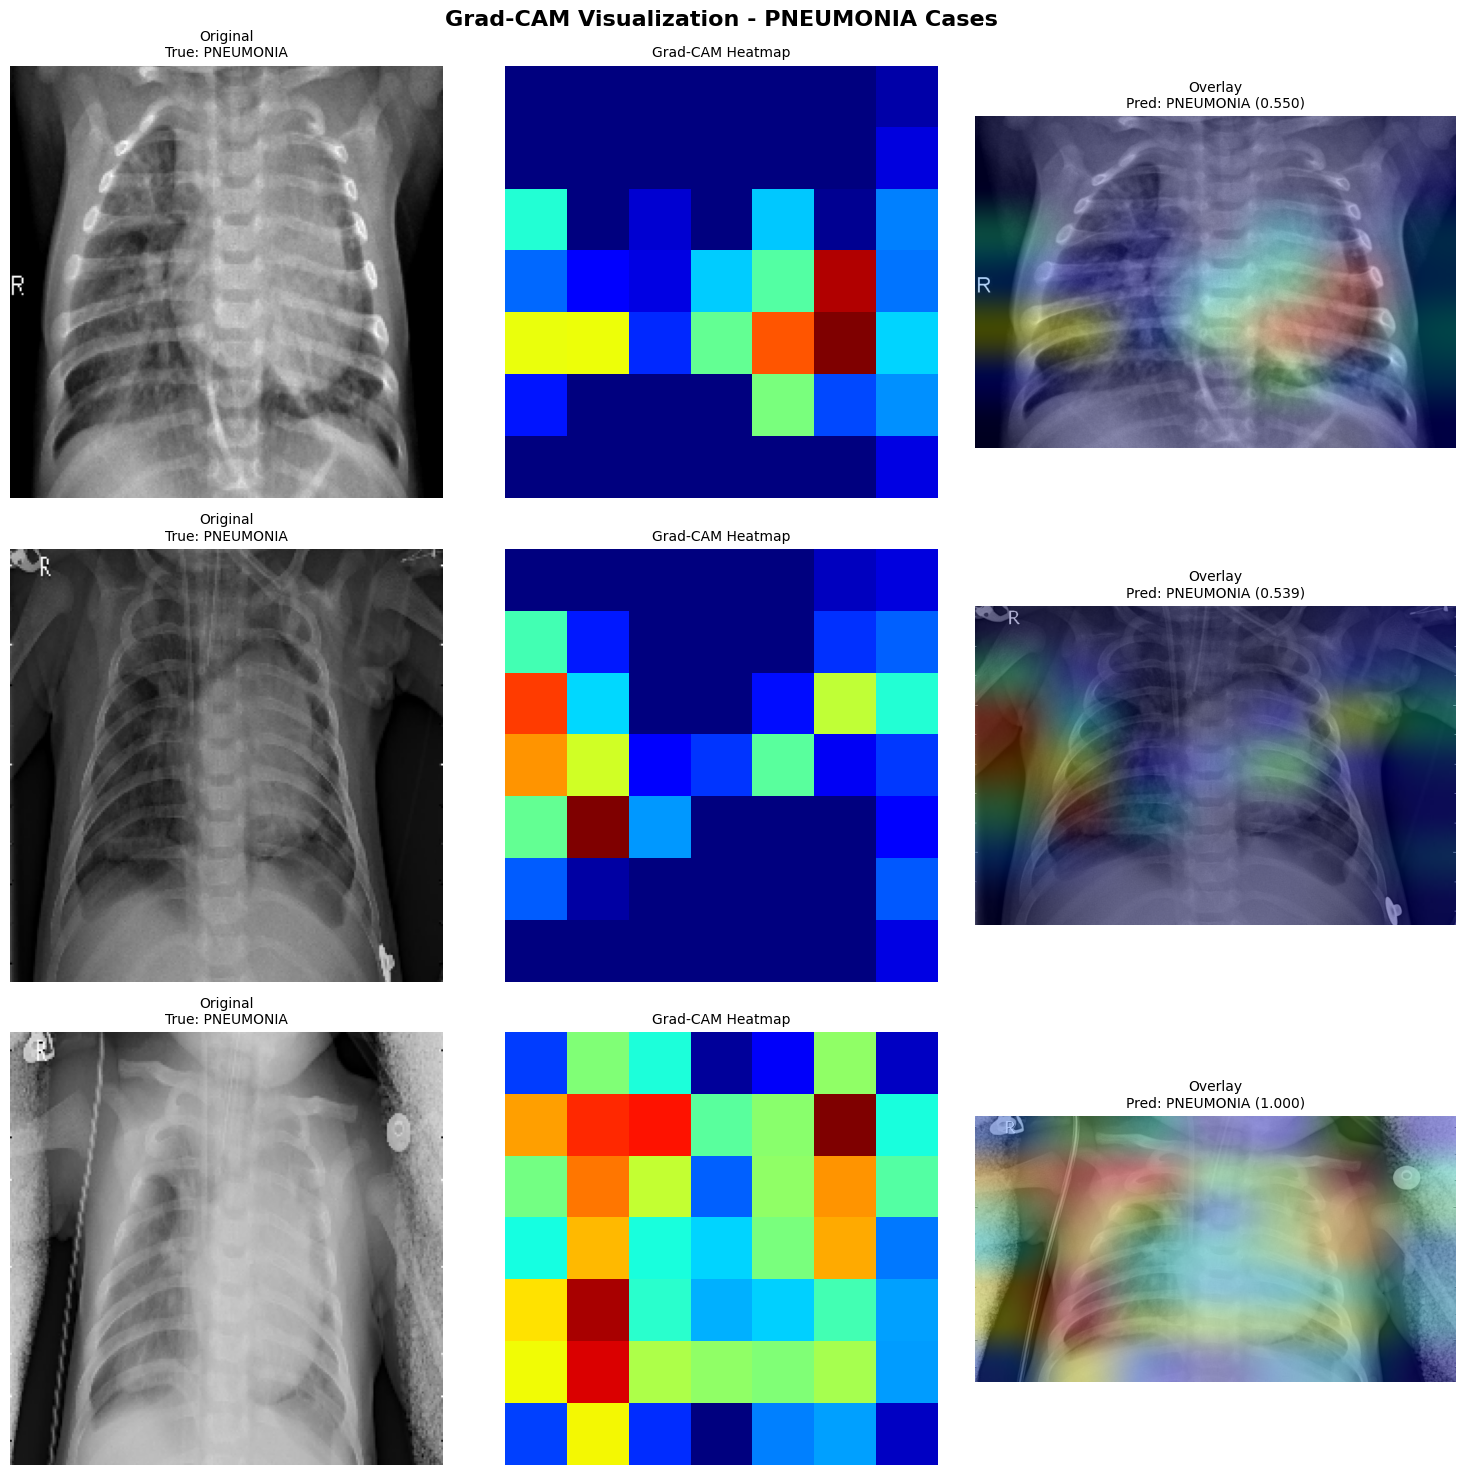

 Grad-CAM visualizations saved to: C:\Python\ML Intro\Projects\Medical Image Classification\results\plots\gradcam


In [32]:
print("\n" + "="*70)
print(" GENERATING GRAD-CAM FOR PNEUMONIA CASES")
print("="*70)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for idx, img_path in enumerate(pneumonia_images):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    
    # Get prediction
    pred = model.predict(img_array, verbose=0)[0][0]
    pred_class = "PNEUMONIA" if pred > 0.5 else "NORMAL"
    
    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array, gradcam_model)
    
    # Save Grad-CAM overlay
    cam_path = gradcam_dir / f'pneumonia_{idx}_gradcam.jpg'
    superimposed_img = save_and_display_gradcam(str(img_path), heatmap, str(cam_path))
    
    # Display
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f'Original\nTrue: PNEUMONIA', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(heatmap, cmap='jet')
    axes[idx, 1].set_title(f'Grad-CAM Heatmap', fontsize=10)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(superimposed_img)
    axes[idx, 2].set_title(f'Overlay\nPred: {pred_class} ({pred:.3f})', fontsize=10)
    axes[idx, 2].axis('off')

plt.suptitle('Grad-CAM Visualization - PNEUMONIA Cases', fontsize=16, fontweight='bold')
plt.tight_layout()

save_path = gradcam_dir / 'gradcam_pneumonia_cases.png'
plt.savefig(str(save_path), dpi=300, bbox_inches='tight')
plt.show()

print(f" Grad-CAM visualizations saved to: {gradcam_dir}")

In [31]:
print("\n" + "="*70)
print(" GRAD-CAM VISUALIZATION COMPLETE!")
print("="*70)

print(f"\n All files saved to:")
print(f"   {gradcam_dir}")

print(f"\n Generated visualizations:")
print(f"    3 NORMAL case overlays")
print(f"    3 PNEUMONIA case overlays")
print(f"    2 summary plots")

print(f"\n What the heatmaps show:")
print(f"    Red areas = Model focused heavily here")
print(f"    Yellow areas = Moderate attention")
print(f"    Blue/Green areas = Less important for prediction")

print(f"\n Interpretation:")
print(f"   - For PNEUMONIA: Model should focus on lung infiltrates/opacity")
print(f"   - For NORMAL: Model should show distributed attention")

print("\n Next: Create Streamlit web app!")
print("="*70)


 GRAD-CAM VISUALIZATION COMPLETE!

 All files saved to:
   C:\Python\ML Intro\Projects\Medical Image Classification\results\plots\gradcam

 Generated visualizations:
    3 NORMAL case overlays
    3 PNEUMONIA case overlays
    2 summary plots

 What the heatmaps show:
    Red areas = Model focused heavily here
    Yellow areas = Moderate attention
    Blue/Green areas = Less important for prediction

 Interpretation:
   - For PNEUMONIA: Model should focus on lung infiltrates/opacity
   - For NORMAL: Model should show distributed attention

 Next: Create Streamlit web app!
